#### Mount drive

In [ ]:
# Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#### Install required libraries

In [ ]:
!pip install -r /content/drive/MyDrive/GNR638_GROUP28_ASSIGNMENT_2/requirements.txt

#### Project Structure

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/GNR638_GROUP28_ASSIGNMENT_2"

folders = [
    "src",
    "notebooks",
    "results",
    "plots",
    "logs",
    "checkpoints",
    "dataset"
]

for f in folders:
  os.makedirs(os.path.join(BASE_DIR, f), exist_ok=True)

print("Project structure created")

Project structure created


In [ ]:
pyproject = os.path.join(BASE_DIR, "pyproject.toml")
if not os.path.exists(pyproject):
  open(pyproject, "w").close()

gitignore = os.path.join(BASE_DIR, ".gitignore")
if not os.path.exists(gitignore):
  open(gitignore, "w").close()

requirements = os.path.join(BASE_DIR, "requirements.txt")
if not os.path.exists(requirements):
  open(requirements, "w").close()

In [ ]:
# create empty module files
src = "/content/drive/MyDrive/GNR638_GROUP28_ASSIGNMENT_2/src"
os.makedirs(os.path.join(src, "cnn_transfer"), exist_ok=True)

module_files = [
    "dataset.py",
    "models.py",
    "train.py",
    "evaluate.py",
    "corruption.py",
    "feature_probe.py",
    "utils.py"
]

for m in module_files:
  path = os.path.join(src, "cnn_transfer" , m)
  if not os.path.exists(path):
    open(path, "w").close()

print("Module files created")

Module files created


In [ ]:
src_init = os.path.join(src, "cnn_transfer" , "__init__.py")
if not os.path.exists(src_init):
  open(src_init, "w").close()

In [ ]:
save_folders = [
    "results",
    "plots",
    "logs",
    "checkpoints",
]

models = [
    "resnet50",
    "densenet121",
    "efficientnet_b0"
]

for i in save_folders:
  for j in models:
    folder_path = os.path.join(BASE_DIR, i)
    path = os.path.join(folder_path, j)
    os.makedirs(path, exist_ok=True)

In [ ]:
!apt-get install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (157 kB/s)
Selecting previously unselected package tree.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../tree_2.0.2-1_amd64.deb ...
Unpacking tree (2.0.2-1) ...
Setting up tree (2.0.2-1) ...
Processing triggers for man-db (2.10.2-1) ...


In [ ]:
!tree -a /content/drive/MyDrive/GNR638_GROUP28_ASSIGNMENT_2 -I "dataset"

/content/drive/MyDrive/GNR638_GROUP28_ASSIGNMENT_2
├── checkpoints
│   ├── densenet121
│   ├── efficientnet_b0
│   └── resnet50
├── .gitignore
├── logs
│   ├── densenet121
│   ├── efficientnet_b0
│   └── resnet50
├── notebooks
│   └── experiments_resnet50.ipynb
├── plots
│   ├── densenet121
│   ├── efficientnet_b0
│   └── resnet50
├── pyproject.toml
├── requirements.txt
├── results
│   ├── densenet121
│   ├── efficientnet_b0
│   └── resnet50
└── src
    └── cnn_transfer
        ├── corruption.py
        ├── dataset.py
        ├── evaluate.py
        ├── feature_probe.py
        ├── __init__.py
        ├── models.py
        ├── train.py
        └── utils.py

19 directories, 12 files


#### Install custom package in colab

In [ ]:
!pip uninstall cnn-transfer -y
!pip install -e /content/drive/MyDrive/GNR638_GROUP28_ASSIGNMENT_2

Found existing installation: cnn-transfer 0.1.0
Uninstalling cnn-transfer-0.1.0:
  Successfully uninstalled cnn-transfer-0.1.0
Obtaining file:///content/drive/MyDrive/GNR638_GROUP28_ASSIGNMENT_2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for cnn-transfer (pyproject.toml) ... done
  Created wheel for cnn-transfer: filename=cnn_transfer-0.1.0-0.editable-py3-none-any.whl size=1382 sha256=78fe7776047c12f685dbc6c74f1cddb47bcf8c84b0a626e0dd6489b111940114
  Stored in directory: /tmp/pip-ephem-wheel-cache-fs1s0nkm/wheels/69/e9/b2/657fe87ceba1b00e6bb32fa792dce85549fbe718f9c0c0558e
Successfully built cnn-transfer


#### Import custom modules

In [ ]:
import cnn_transfer
from cnn_transfer.dataset import *
from cnn_transfer.models import *
from cnn_transfer.train import *
from cnn_transfer.evaluate import *
from cnn_transfer.corruption import *
from cnn_transfer.feature_probe import *
from cnn_transfer.utils import *

#### Import required libraries

In [ ]:
import os
import json
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import importlib

#### Set seed

In [ ]:
BASE_DIR = "/content/drive/MyDrive/GNR638_GROUP28_ASSIGNMENT_2"
from cnn_transfer.utils import set_seed
set_seed(42)

#### Device

In [ ]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


---
### Global Config
---

In [ ]:
config = {
    "model_name": "resnet50",
    "batch_size": 64,
    "lr": 3e-4,
    "epochs": 20,
    "num_classes": 30,
    "img_size": 224,
    "data_dir": BASE_DIR + "/dataset/train_data"}

### Dataset

#### Load Dataset

In [ ]:
dataset, train_t, val_t = load_dataset(
    config["data_dir"],
    config["img_size"]
)

#### Train / Validation split

In [ ]:
train_dataset, val_dataset = create_train_val_split(dataset)
# Attach Transforms
train_dataset.dataset.transform = train_t
val_dataset.dataset.transform = val_t

#### Create DataLoaders

In [ ]:
train_loader, val_loader = create_dataloaders(
    train_dataset,
    val_dataset,
    config["batch_size"]
)

print(len(train_dataset), len(val_dataset))

5945 1048


#### Chosen Models:
* resnet50
* densenet121
* efficienet_b0

## ResNet50

## 4.1 Linear Probe Transfer

#### Load Model

In [ ]:
model = load_model(
    config["model_name"],
    config["num_classes"])
model = model.to(device)

#### Efficiency Metrics

In [ ]:
print_model_stats(model, config["model_name"])

Model Efficiency Metrics: resnet50
------------------------
Parameters: 23.57 M
MACs: 4.13 G
FLOPs: 8.26 G


#### Freeze Backbone

In [ ]:
model = load_model(
    config["model_name"],
    config["num_classes"])
model = freeze_backbone(model)
model = model.to(device)

In [ ]:
trainable, total = count_trainable_params(model)
print(f"Trainable params: {trainable}")
print(f"Total params: {total}")
print(f"Trainable %: {100*trainable/total:.2f}%")

Trainable params: 61470
Total params: 23569502
Trainable %: 0.26%


#### Define Optimizer


In [ ]:
# only trainable parameters should be optimized
import torch.optim as optim

#Adamw optimizer
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=config["lr"]
)

#### Loss Function

In [ ]:
import torch.nn as nn
criterion = nn.CrossEntropyLoss()

#### Train Linear classifier

------------Debugging-----------------

In [ ]:
print("Model device:", next(model.parameters()).device)

images, labels = next(iter(train_loader))
print("Image device before:", images.device)

images = images.to(device)
print("Image device after:", images.device)

Model device: cuda:0
Image device before: cpu
Image device after: cuda:0


In [ ]:
images, labels = next(iter(train_loader))
print(images.shape)

torch.Size([64, 3, 224, 224])


In [ ]:
import time

images, labels = next(iter(train_loader))

images = images.to(device)

torch.cuda.synchronize()
start = time.time()

_ = model(images)

torch.cuda.synchronize()
print("Forward time:", time.time() - start)

Forward time: 0.23635649681091309


#### Train

In [ ]:
from cnn_transfer.train import train_model

history = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=config["epochs"]
)

Epoch 1/20


100%|██████████| 93/93 [06:54<00:00,  4.46s/it]


Train Acc: 0.2713 | Val Acc: 0.5006 | Grad Norm: 0.8393
Epoch 2/20


100%|██████████| 93/93 [01:18<00:00,  1.19it/s]


Train Acc: 0.5674 | Val Acc: 0.6121 | Grad Norm: 0.8213
Epoch 3/20


...

Train Acc: 0.8543 | Val Acc: 0.8027 | Grad Norm: 0.4884
Epoch 19/20


100%|██████████| 93/93 [01:44<00:00,  1.12s/it]


Train Acc: 0.8568 | Val Acc: 0.8094 | Grad Norm: 0.4871
Epoch 20/20


100%|██████████| 93/93 [01:49<00:00,  1.18s/it]


Train Acc: 0.8604 | Val Acc: 0.8091 | Grad Norm: 0.4713


#### Save logs and the trained model

In [ ]:
save_model_logs_dir = os.path.join(BASE_DIR, "logs", config["model_name"])
os.makedirs(save_model_logs_dir, exist_ok=True)

save_model_dir = os.path.join(BASE_DIR, "checkpoints", config["model_name"])
os.makedirs(save_model_dir, exist_ok=True)

In [ ]:
# save history(acc,loss)
history_json_file = os.path.join(save_model_logs_dir, "4.1_history.json")
with open(history_json_file, "w") as f:
    json.dump(history, f)

# save the trained model
model_path = os.path.join(save_model_dir, "4.1_model_final.pt")
torch.save(model.state_dict(), model_path)

### Evaluation

In [ ]:
save_model_logs_dir = os.path.join(BASE_DIR, "logs", config["model_name"])
os.makedirs(save_model_logs_dir, exist_ok=True)

save_model_dir = os.path.join(BASE_DIR, "checkpoints", config["model_name"])
os.makedirs(save_model_dir, exist_ok=True)

history_json_file = os.path.join(save_model_logs_dir, "4.1_history.json")
with open(history_json_file, "r") as f:
    history = json.load(f)

model_path = os.path.join(save_model_dir, "4.1_model_final.pt")
model.load_state_dict(torch.load(model_path))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act1): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act1): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (drop_block): Identity()
      (act2): ReLU(inplace=True)
      (aa): Identity()
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

#### Plot Accuracy Curves


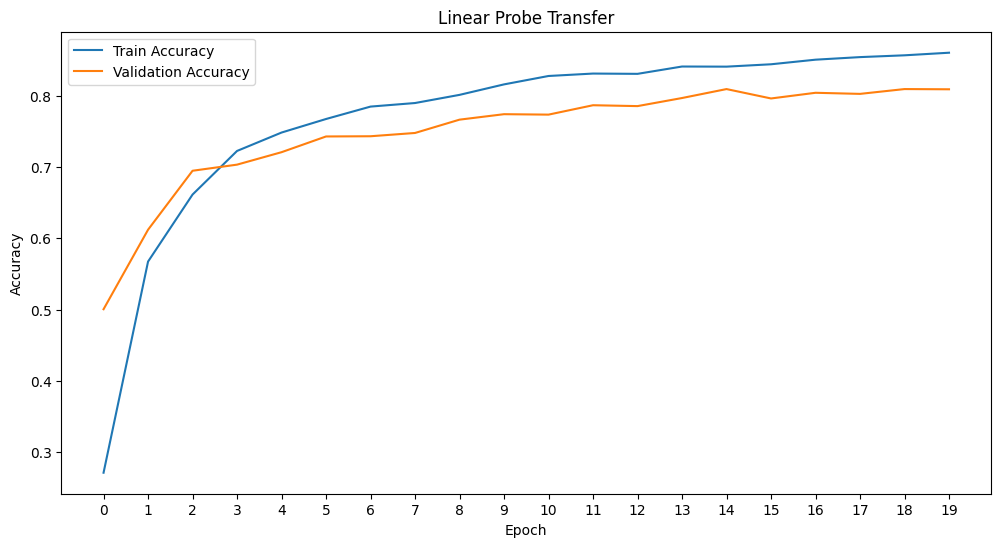

In [ ]:
# Training and validation accuracy curves
from cnn_transfer.evaluate import plot_train_val_acc_curves_and_save
plot_train_val_acc_curves_and_save(history, config['model_name'], BASE_DIR)

#### Confusion Matrix

Check if image is saved correctly in the google drive.If not save manually


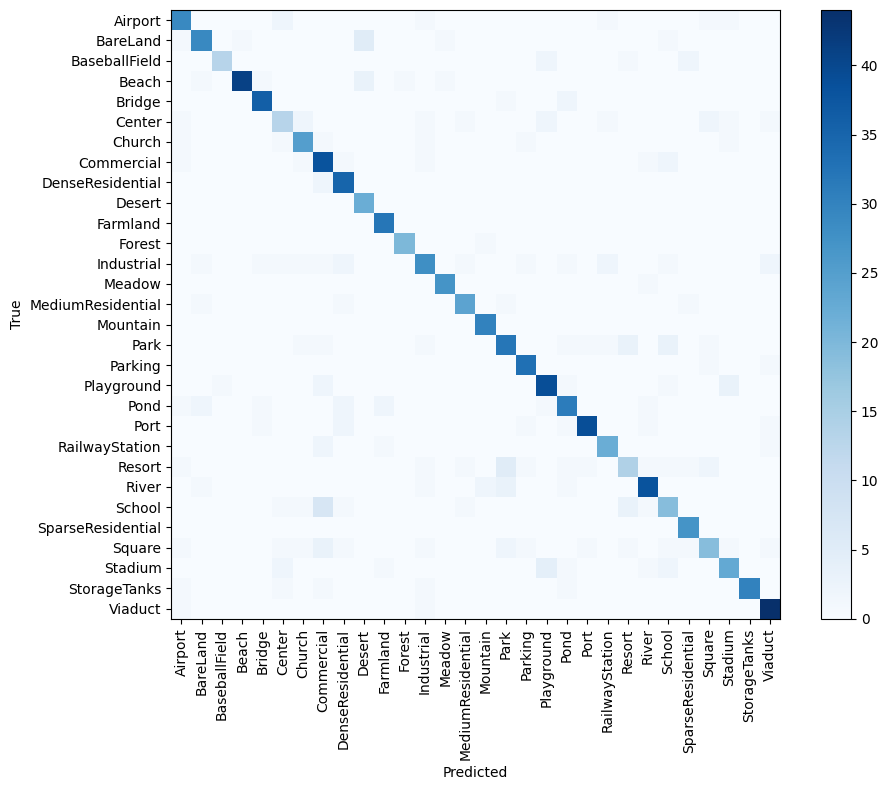

<Figure size 640x480 with 0 Axes>

In [ ]:
from cnn_transfer.evaluate import plot_confusion_matrix_and_save
plot_confusion_matrix_and_save(model, val_loader, device, BASE_DIR, config["model_name"], dataset)

#### Feature Embedding Visualization

In [ ]:
from cnn_transfer.evaluate import extract_features
features, labels = extract_features(model,val_loader,device)

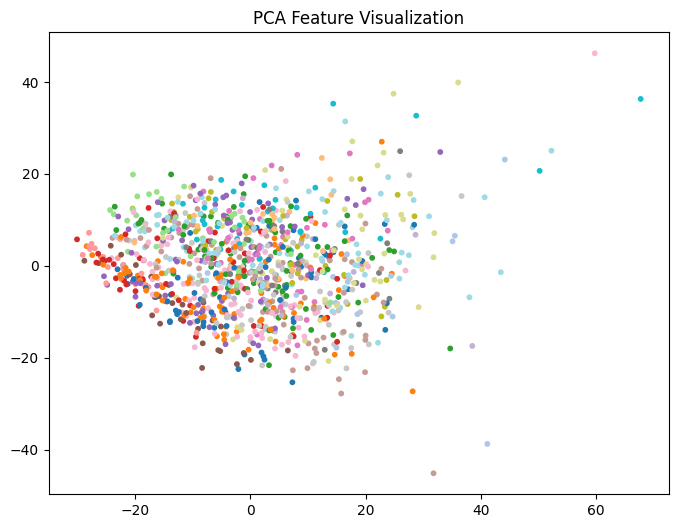

In [ ]:
# PCA
from cnn_transfer.evaluate import plot_pca
plot_pca(features, labels, BASE_DIR, config["model_name"])

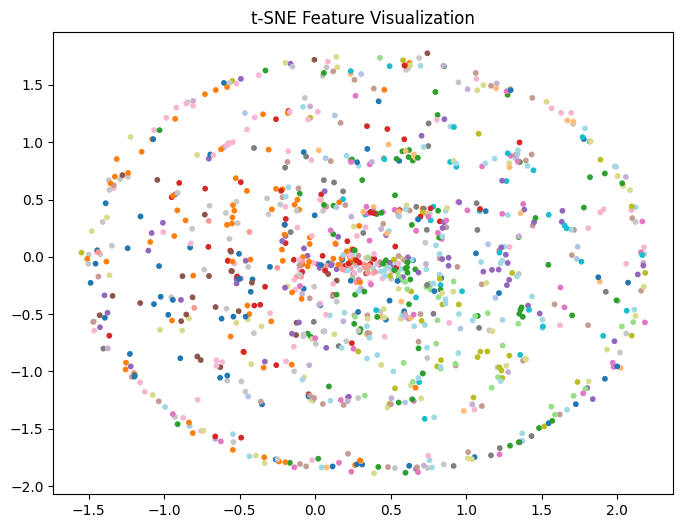

In [ ]:
# t-SNE
from cnn_transfer.evaluate import plot_tsne
plot_tsne(features, labels, BASE_DIR, config["model_name"])

## 4.2 Fine-Tuning Strategies

##### set_hyperparmeters

* No_of_epochs = 10

In [ ]:
def set_hyperparameters(model):

    set_seed(42)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"]
    )

    return criterion, optimizer

In [ ]:
save_model_logs_dir = os.path.join(BASE_DIR, "logs", config["model_name"])
os.makedirs(save_model_logs_dir, exist_ok=True)

save_model_dir = os.path.join(BASE_DIR, "checkpoints", config["model_name"])
os.makedirs(save_model_dir, exist_ok=True)

##### Linear probe

In [ ]:
model = load_model(
        config["model_name"],
        config["num_classes"])

model = freeze_backbone(model)
model = model.to(device)
criterion, optimizer = set_hyperparameters(model)

In [ ]:
trainable, total = count_trainable_params(model)
print(f"Trainable params: {trainable}")
print(f"Total params: {total}")
print(f"Trainable %: {100*trainable/total:.2f}%")

Trainable params: 61470
Total params: 23569502
Trainable %: 0.26%


In [ ]:
# train
from cnn_transfer.train import train_model

history_linear_probe = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10)

Epoch 1/10


100%|██████████| 93/93 [01:18<00:00,  1.18it/s]


Train Acc: 0.2435 | Val Acc: 0.4945 | Grad Norm: 0.8358
Epoch 2/10


100%|██████████| 93/93 [01:20<00:00,  1.16it/s]


Train Acc: 0.5668 | Val Acc: 0.6464 | Grad Norm: 0.8120
Epoch 3/10


...

Train Acc: 0.7977 | Val Acc: 0.7613 | Grad Norm: 0.6449
Epoch 9/10


100%|██████████| 93/93 [01:18<00:00,  1.18it/s]


Train Acc: 0.8068 | Val Acc: 0.7693 | Grad Norm: 0.6174
Epoch 10/10


100%|██████████| 93/93 [01:21<00:00,  1.14it/s]


Train Acc: 0.8102 | Val Acc: 0.7623 | Grad Norm: 0.6059


In [ ]:
# save history(acc,loss)
history_json_file = os.path.join(save_model_logs_dir, "4.2_linear_probe_history.json")
with open(history_json_file, "w") as f:
    json.dump(history_linear_probe, f)

# save the trained model
model_path = os.path.join(save_model_dir, "4.2_linear_probe_model.pt")
torch.save(model.state_dict(), model_path)

##### Last block + Classifier fine-tuning

In [ ]:
model = load_model(
        config["model_name"],
        config["num_classes"])

model = freeze_everything(model)
# for name, p in model.named_parameters():
#     if p.requires_grad:
#         print(name)
model = unfreeze_last_block(model,config["model_name"])
model = unfreeze_classifier(model)
# for name, p in model.named_parameters():
#     if p.requires_grad:
#         print(name)
# model = model.to(device)

criterion, optimizer = set_hyperparameters(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
trainable, total = count_trainable_params(model)
print(f"Trainable params: {trainable}")
print(f"Total params: {total}")
print(f"Trainable %: {100*trainable/total:.2f}%")

Trainable params: 15026206
Total params: 23569502
Trainable %: 63.75%


In [ ]:
# train
from cnn_transfer.train import train_model

history_last_block = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10)

Epoch 1/10


100%|██████████| 93/93 [01:27<00:00,  1.06it/s]


Train Acc: 0.4126 | Val Acc: 0.6826 | Grad Norm: 1.0677
Epoch 2/10


100%|██████████| 93/93 [01:33<00:00,  1.01s/it]


Train Acc: 0.8023 | Val Acc: 0.8624 | Grad Norm: 1.1288
Epoch 3/10


...

Train Acc: 0.9960 | Val Acc: 0.9252 | Grad Norm: 0.2219
Epoch 9/10


100%|██████████| 93/93 [01:21<00:00,  1.14it/s]


Train Acc: 0.9973 | Val Acc: 0.9243 | Grad Norm: 0.1768
Epoch 10/10


100%|██████████| 93/93 [01:21<00:00,  1.14it/s]


Train Acc: 0.9980 | Val Acc: 0.9268 | Grad Norm: 0.1525


In [ ]:
# save history(acc,loss)
history_json_file = os.path.join(save_model_logs_dir, "4.2_last_block_csf_unfreeze_history.json")
with open(history_json_file, "w") as f:
    json.dump(history_last_block, f)

# save the trained model
model_path = os.path.join(save_model_dir, "4.2_last_block_csf_unfreeze_model.pt")
torch.save(model.state_dict(), model_path)

##### Full Fine-Tuning


In [ ]:
model = load_model(
        config["model_name"],
        config["num_classes"])

model = freeze_everything(model)
model = unfreeze_all(model)
model = model.to(device)
criterion, optimizer = set_hyperparameters(model)

In [ ]:
trainable, total = count_trainable_params(model)
print(f"Trainable params: {trainable}")
print(f"Total params: {total}")
print(f"Trainable %: {100*trainable/total:.2f}%")

Trainable params: 23569502
Total params: 23569502
Trainable %: 100.00%


In [ ]:
# train
from cnn_transfer.train import train_model

history_full_finetune = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10)

Epoch 1/10


100%|██████████| 93/93 [01:37<00:00,  1.05s/it]


Train Acc: 0.4689 | Val Acc: 0.7831 | Grad Norm: 1.7409
Epoch 2/10


100%|██████████| 93/93 [02:03<00:00,  1.33s/it]


Train Acc: 0.8715 | Val Acc: 0.9062 | Grad Norm: 1.8280
Epoch 3/10


...

Train Acc: 0.9985 | Val Acc: 0.9452 | Grad Norm: 0.3447
Epoch 9/10


100%|██████████| 93/93 [01:36<00:00,  1.04s/it]


Train Acc: 0.9970 | Val Acc: 0.9433 | Grad Norm: 0.3634
Epoch 10/10


100%|██████████| 93/93 [01:34<00:00,  1.02s/it]


Train Acc: 0.9976 | Val Acc: 0.9488 | Grad Norm: 0.3813


In [ ]:
# save history(acc,loss)
history_json_file = os.path.join(save_model_logs_dir, "4.2_full_finetune_history.json")
with open(history_json_file, "w") as f:
    json.dump(history_full_finetune, f)

# save the trained model
model_path = os.path.join(save_model_dir, "4.2_full_finetune_model.pt")
torch.save(model.state_dict(), model_path)

##### Selective 20% Unfreeze

* Deeper layers capture high-level semantic features
and adapt better to new tasks, so unfreezing them first

In [ ]:
model = load_model(
        config["model_name"],
        config["num_classes"])

model = freeze_everything(model)
model = unfreeze_percentage(model,0.2)
model = model.to(device)

criterion, optimizer = set_hyperparameters(model)

In [ ]:
trainable, total = count_trainable_params(model)
print(f"Trainable params: {trainable}")
print(f"Total params: {total}")
print(f"Trainable %: {100*trainable/total:.2f}%")

Trainable params: 4528158
Total params: 23569502
Trainable %: 19.21%


In [ ]:
# train
from cnn_transfer.train import train_model

history_selective_20 = train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    device,
    epochs=10)

Epoch 1/10


100%|██████████| 93/93 [01:16<00:00,  1.22it/s]


Train Acc: 0.3228 | Val Acc: 0.5398 | Grad Norm: 0.9471
Epoch 2/10


100%|██████████| 93/93 [01:30<00:00,  1.03it/s]


Train Acc: 0.6529 | Val Acc: 0.7230 | Grad Norm: 1.0464
Epoch 3/10


...

Train Acc: 0.9424 | Val Acc: 0.8876 | Grad Norm: 0.5655
Epoch 9/10


100%|██████████| 93/93 [01:16<00:00,  1.22it/s]


Train Acc: 0.9561 | Val Acc: 0.9029 | Grad Norm: 0.5131
Epoch 10/10


100%|██████████| 93/93 [01:17<00:00,  1.20it/s]


Train Acc: 0.9663 | Val Acc: 0.8971 | Grad Norm: 0.4618


In [ ]:
# save history(acc,loss)
history_json_file = os.path.join(save_model_logs_dir, "4.2_selective_20_unfreeze_history.json")
with open(history_json_file, "w") as f:
    json.dump(history_selective_20, f)

# save the trained model
model_path = os.path.join(save_model_dir, "4.2_selective_20_unfreeze_model.pt")
torch.save(model.state_dict(), model_path)

#### Comparison

In [ ]:
log_dir = save_model_logs_dir

histories = {}

files = {
    "linear_probe": "4.2_linear_probe_history.json",
    "selective_20": "4.2_selective_20_unfreeze_history.json",
    "last_block": "4.2_last_block_csf_unfreeze_history.json",
    "full_ft": "4.2_full_finetune_history.json"}
for k, f in files.items():
    with open(os.path.join(log_dir, f)) as file:
        histories[k] = json.load(file)

In [ ]:
percent_unfrozen = {
    "linear_probe": 0.26,
    "selective_20": 19.21,
    "last_block": 63.75,
    "full_ft": 100
    }

* Training and Validation Accuracy vs % Parameters

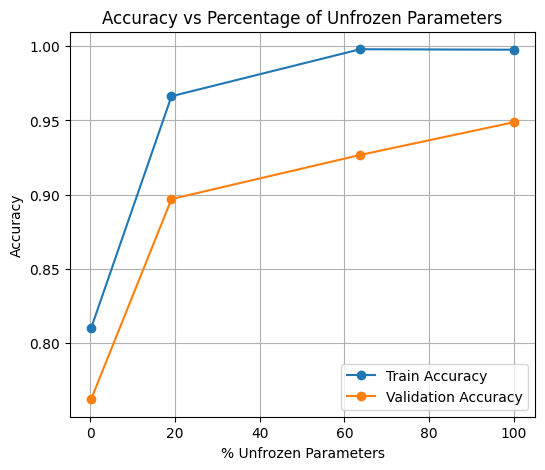

In [ ]:
from cnn_transfer.evaluate import plot_train_val_acc_percentage_param
plot_train_val_acc_percentage_param(histories, percent_unfrozen,BASE_DIR,config["model_name"])

* Convergence Stability (Training Loss vs Epoch)

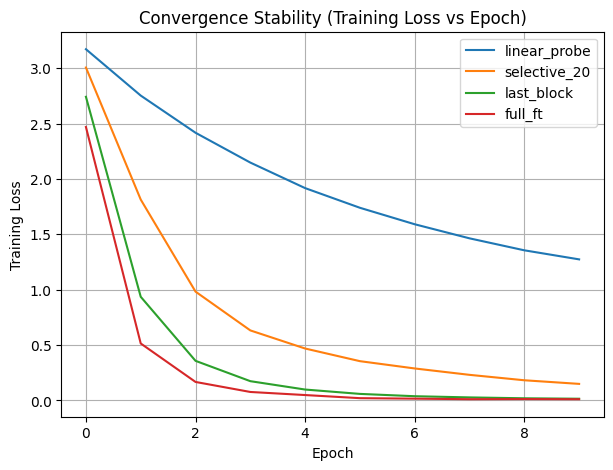

In [ ]:
from cnn_transfer.evaluate import plot_train_loss_vs_epoch
plot_train_loss_vs_epoch(histories,BASE_DIR,config["model_name"])

* Gradient Norm Statistics

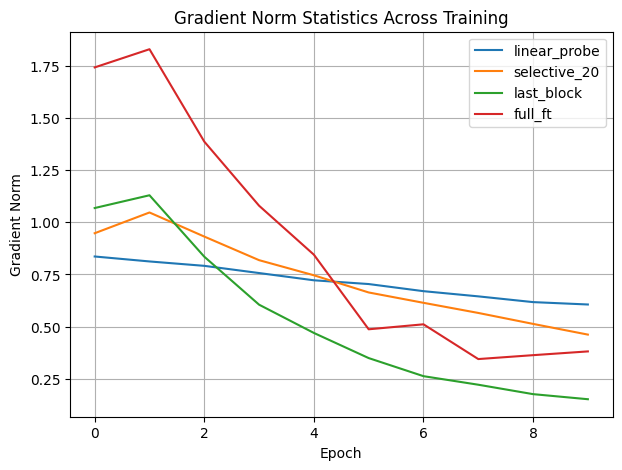

In [ ]:
from cnn_transfer.evaluate import grad_norm_stats
grad_norm_stats(histories,BASE_DIR,config["model_name"])

* summary Table

In [ ]:
from cnn_transfer.evaluate import summary_table
summary_table(histories, percent_unfrozen,BASE_DIR,config["model_name"])

,strategy,%params,final_val_acc,final_train_acc
0,linear_probe,0.26,0.762255,0.810236
1,selective_20,19.21,0.897059,0.966315
2,last_block,63.75,0.926777,0.997984
3,full_ft,100.00,0.948836,0.997648


## 4.3 Few-Shot Learning Analysis

#### Train

In [ ]:
fractions = [1.0, 0.2, 0.05]

train_sets = {}

for f in fractions:

    if f == 1.0:
        train_sets[f] = train_dataset
    else:
        train_sets[f] = create_fewshot_subset(train_dataset, f, seed=42)

In [ ]:
import torch.optim as optim
import torch.nn as nn

fewshot_results = {}

for frac in fractions:

    print("="*50)
    print(f"Training using {frac*100}% data")
    print("="*50)

    model = load_model(
        config["model_name"],
        config["num_classes"]
    )

    model = freeze_backbone(model)
    model = model.to(device)

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=config["lr"]
    )

    criterion = nn.CrossEntropyLoss().to(device)

    train_loader, val_loader = create_dataloaders(
        train_sets[frac],
        val_dataset,
        batch_size=config["batch_size"]
    )

    history = train_model(
        model,
        train_loader,
        val_loader,
        optimizer,
        criterion,
        device,
        epochs=10
    )

    fewshot_results[frac] = history

Training using 100.0% data
Epoch 1/10


100%|██████████| 93/93 [17:37<00:00, 11.37s/it]


Train Acc: 0.2782 | Val Acc: 0.4969 | Grad Norm: 0.8422
Epoch 2/10


100%|██████████| 93/93 [01:13<00:00,  1.27it/s]


Train Acc: 0.5678 | Val Acc: 0.6100 | Grad Norm: 0.8080
Epoch 3/10


...

Train Acc: 0.2453 | Val Acc: 0.1415 | Grad Norm: 0.8308
Epoch 9/10


100%|██████████| 5/5 [00:03<00:00,  1.43it/s]


Train Acc: 0.2822 | Val Acc: 0.1489 | Grad Norm: 0.8237
Epoch 10/10


100%|██████████| 5/5 [00:03<00:00,  1.47it/s]


Train Acc: 0.3423 | Val Acc: 0.1688 | Grad Norm: 0.8369


In [ ]:
save_model_logs_dir = os.path.join(BASE_DIR, "logs", config["model_name"])
os.makedirs(save_model_logs_dir, exist_ok=True)

save_model_dir = os.path.join(BASE_DIR, "checkpoints", config["model_name"])
os.makedirs(save_model_dir, exist_ok=True)

for frac in fractions:
  # save history(acc,loss)
  history_json_file = os.path.join(save_model_logs_dir, f"4.3_few_shot_{frac}.json")
  with open(history_json_file, "w") as f:
      json.dump(fewshot_results[frac], f)

#### Evaluation

In [ ]:
import json
import os

save_model_logs_dir = os.path.join(BASE_DIR, "logs", config["model_name"])
os.makedirs(save_model_logs_dir, exist_ok=True)

save_model_dir = os.path.join(BASE_DIR, "checkpoints", config["model_name"])
os.makedirs(save_model_dir, exist_ok=True)

fewshot_results = {}

fractions = [1.0, 0.2, 0.05]

for frac in fractions:

    history_json_file = os.path.join(
        save_model_logs_dir,
        f"4.3_few_shot_{frac}.json"
    )

    with open(history_json_file, "r") as f:
        fewshot_results[frac] = json.load(f)

##### Validation Accuracy

In [ ]:
acc_100 = fewshot_results[1.0]["val_acc"][-1]
acc_20  = fewshot_results[0.2]["val_acc"][-1]
acc_5   = fewshot_results[0.05]["val_acc"][-1]
print(f"Val_Acc_100:{acc_100:.4f}, Val_Acc_20:{acc_20:.4f}, Val_Acc_5:{acc_5:.4f}")

Val_Acc_100:0.7727, Val_Acc_20:0.5656, Val_Acc_5:0.1688


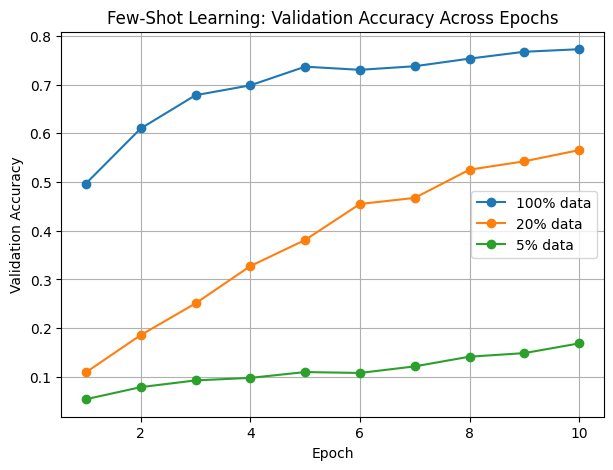

In [ ]:
from cnn_transfer.evaluate import plot_val_acc_across_epochs
plot_val_acc_across_epochs(fewshot_results,BASE_DIR,config["model_name"])

##### Relative Performance Drop

In [ ]:
delta = (acc_100 - acc_5) / acc_100
print(f"Relative performance drop:{delta:.4f}")

Relative performance drop:0.7815


##### Training–Validation Gap

In [ ]:
# measures overfitting
train_acc = fewshot_results[frac]["train_acc"][-1]
val_acc   = fewshot_results[frac]["val_acc"][-1]

gap = train_acc - val_acc
print(f"Training–validation gap:{gap:.4f}")

Training–validation gap:0.1735


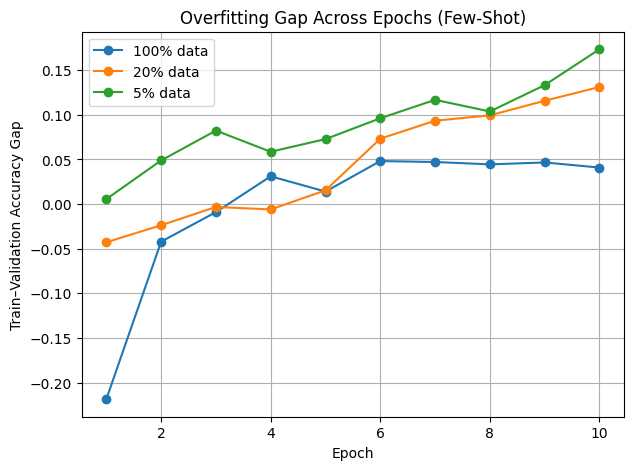

In [ ]:
from cnn_transfer.evaluate import train_val_acc_gap_acroos_epochs
train_val_acc_gap_acroos_epochs(fewshot_results,BASE_DIR,config["model_name"])

##### Plot Data Efficiency(Accuracy vs Data Fraction)

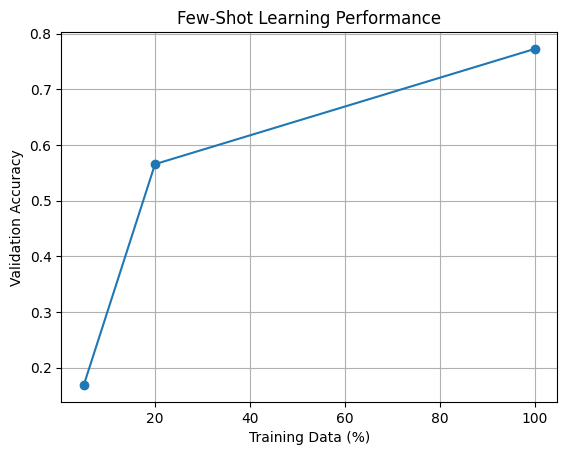

In [ ]:
data_sizes = [100, 20, 5]
acc_100 = fewshot_results[1.0]["val_acc"][-1]
acc_20  = fewshot_results[0.2]["val_acc"][-1]
acc_5   = fewshot_results[0.05]["val_acc"][-1]
accs = [acc_100, acc_20, acc_5]

from cnn_transfer.evaluate import plot_acc_vs_data_frac
plot_acc_vs_data_frac(fewshot_results,data_sizes,accs,BASE_DIR,config["model_name"])

## 4.4 Corruption Robustness Evaluation

In [ ]:
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from PIL import Image
import random
from cnn_transfer.corruption import *

In [ ]:
model = load_model(config["model_name"], config["num_classes"])
model_path = os.path.join(BASE_DIR,"checkpoints/resnet50/4.2_full_finetune_model.pt")
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()
criterion = torch.nn.CrossEntropyLoss().to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


#### Evaluation

In [ ]:
from cnn_transfer.corruption import corruption_robustness_analysis
results, acc_clean = corruption_robustness_analysis(model, val_loader, criterion, device)

In [ ]:
save_model_logs_dir = os.path.join(BASE_DIR, "logs", config["model_name"])
os.makedirs(save_model_logs_dir, exist_ok=True)

history_json_file = os.path.join(save_model_logs_dir, f"4.4_corruption_robustness_analysis.json")
with open(history_json_file, "w") as f:
    json.dump(results, f)

In [ ]:
import pandas as pd

df = pd.DataFrame(results).T

results_dir = os.path.join(BASE_DIR, "results")
model_dir = os.path.join(results_dir, config["model_name"])
df.to_csv(os.path.join(model_dir, "4.4_corruption_robustness_analysis_results.csv"), index=False)
df

,val_accuracy,corruption_error,relative_robustness
clean,0.948836,0.000000,1.000000
gaussian_0.05,0.816794,0.183206,0.860838
gaussian_0.1,0.476145,0.523855,0.501820
gaussian_0.2,0.049618,0.950382,0.052294
motion_blur,0.865458,0.134542,0.912126
brightness,0.945611,0.054389,0.996601


In [ ]:
import pandas as pd

df = pd.DataFrame(results).T

results_dir = os.path.join(BASE_DIR, "results")
model_dir = os.path.join(results_dir, config["model_name"])
df.to_csv(os.path.join(model_dir, "4.4_corruption_robustness_analysis_results.csv"), index=False)
df

,val_accuracy,corruption_error,relative_robustness
clean,0.948836,0.000000,1.000000
gaussian_0.05,0.816794,0.183206,0.860838
gaussian_0.1,0.476145,0.523855,0.501820
gaussian_0.2,0.049618,0.950382,0.052294
motion_blur,0.865458,0.134542,0.912126
brightness,0.945611,0.054389,0.996601


## 4.5 Layer-Wise Feature Probing

In [ ]:
model = load_model(config["model_name"], config["num_classes"])
model.to(device)

layers = {
    "early": model.layer1,
    "middle": model.layer3,
    "final": model.layer4
}

depth_acc = []
norm_stats = []
layer_features = {}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

##### Extract Features + Train Probe

In [ ]:
for name, layer in layers.items():

    train_feats, train_labels = extract_layer_features(
        model,
        train_loader,
        device,
        layer
    )

    val_feats, val_labels = extract_layer_features(
        model,
        val_loader,
        device,
        layer
    )

    # store features for PCA
    layer_features[name] = val_feats

    acc = train_linear_probe(
        train_feats,
        train_labels,
        val_feats,
        val_labels
    )

    depth_acc.append(acc)

    mean_norm, std_norm = compute_feature_norms(val_feats)

    norm_stats.append((mean_norm, std_norm))

##### Plot Accuracy vs Depth

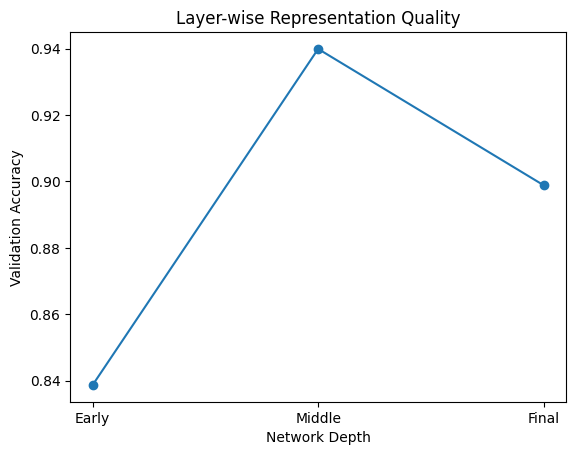

In [ ]:
from cnn_transfer.feature_probe import plot_acc_vs_depth
plot_acc_vs_depth(depth_acc,BASE_DIR,config["model_name"])

##### Feature Norm Statistics

In [ ]:
from cnn_transfer.feature_probe import plot_feature_norms
plot_feature_norms(norm_stats,BASE_DIR,config["model_name"])

        mean_norm  std_norm
Early   18.580799  0.507638
Middle  45.121693  1.378319
Final    7.007725  0.923174


##### PCA Visualization

In [ ]:
val_feats_early = layer_features["early"]
val_feats_mid   = layer_features["middle"]
val_feats_final = layer_features["final"]

def plot_pca(features, labels, BASE_DIR, model_name, layer_name):

    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt
    import os

    pca = PCA(n_components=2)

    reduced = pca.fit_transform(features)

    plt.figure(figsize=(8,6))

    scatter = plt.scatter(
        reduced[:,0],
        reduced[:,1],
        c=labels,
        cmap="tab20",
        s=10
    )

    plt.title(f"{model_name} - {layer_name} Layer PCA")

    plot_dir = os.path.join(BASE_DIR, "plots")
    model_dir = os.path.join(plot_dir, model_name)

    os.makedirs(model_dir, exist_ok=True)

    plt.savefig(
        os.path.join(
            model_dir,
            f"{model_name}_4.5_pca_{layer_name}.png"
        )
    )

    plt.show()

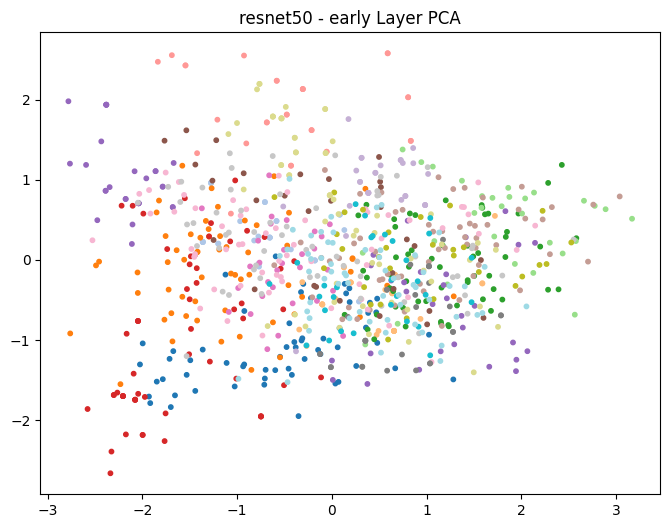

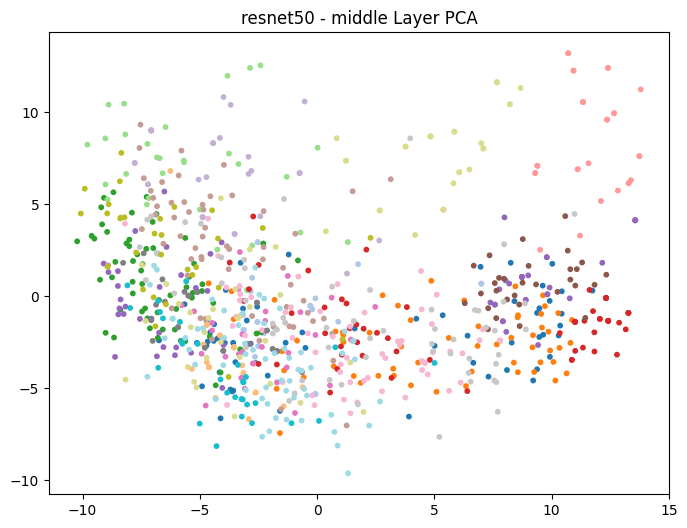

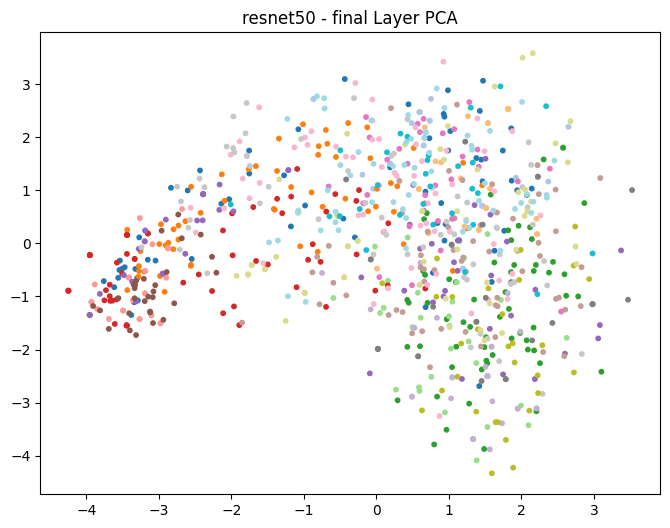

In [ ]:
subset_idx = sample_fixed_subset(val_labels, samples_per_class=30)

subset_feats_early = val_feats_early[subset_idx]
subset_feats_mid   = val_feats_mid[subset_idx]
subset_feats_final = val_feats_final[subset_idx]

subset_labels = val_labels[subset_idx]


plot_pca(
    subset_feats_early,
    subset_labels,
    BASE_DIR,
    config["model_name"],
    "early"
)

plot_pca(
    subset_feats_mid,
    subset_labels,
    BASE_DIR,
    config["model_name"],
    "middle"
)

plot_pca(
    subset_feats_final,
    subset_labels,
    BASE_DIR,
    config["model_name"],
    "final"
)